# Policy Insight Platform — LongFormer Sentiment Classifier

**Single linear flow:**
1. Setup & data loading
2. Data split & quality checks
3. Tokenisation (LongFormer)
4. Model training (LongFormer with weighted loss)
5. Evaluation on test set
6. Threshold tuning on validation set
7. Save model + thresholds
8. --- RESTART POINT ---
9. Inference on unlabelled turns
10. Combine with manual labels & aggregate topic sentiments
11. Exploratory analysis

## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import os
import pickle
import itertools
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    f1_score, accuracy_score,
    classification_report, confusion_matrix
)

from transformers import (
    LongformerTokenizer,
    LongformerForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from datasets import Dataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/PLP_Project/plp_checkpoint')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Load training data

In [ ]:
df = pd.read_csv('final_train_weights.csv', encoding='utf8')

# Belt-and-suspenders label cleaning
df['sentiment_label'] = df['sentiment_label'].str.strip().str.upper()

# Encode labels
le = LabelEncoder()
df['label_id'] = le.fit_transform(df['sentiment_label'])

print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))
print()
print('Class distribution:')
print(df['sentiment_label'].value_counts())
print()
print(df.describe())

Label mapping: {'CAUTIOUS': np.int64(0), 'NEGATIVE': np.int64(1), 'NEUTRAL': np.int64(2), 'POSITIVE': np.int64(3)}

Class distribution:
sentiment_label
CAUTIOUS    334
NEUTRAL     172
POSITIVE     76
NEGATIVE     33
Name: count, dtype: int64

       sample_weight  segment_no    label_id
count     615.000000  615.000000  615.000000
mean        0.883415    7.434146    0.983740
std         0.098447   10.934144    1.148457
min         0.400000    1.000000    0.000000
25%         0.900000    1.000000    0.000000
50%         0.900000    2.000000    0.000000
75%         0.900000    9.000000    2.000000
max         1.000000   77.000000    3.000000


## 3. Train / val / test split

In [ ]:
# 70 / 15 / 15 stratified split
# Smaller splits (80/10/10, 85/7.5/7.5, 90/5/5) failed to keep
# enough NEGATIVE samples in val and test.
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df['label_id']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df['label_id']
)

def verify_split(train_df, val_df, test_df, threshold=5):
    """
    Prints class distribution across all three splits.
    Flags any class falling below threshold in val or test.
    """
    print(f"{'Split':<8} {'Total':>6}  " +
          '  '.join(f'{cls:>10}' for cls in le.classes_))
    print('-' * 65)
    safe = True
    for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
        counts = split['sentiment_label'].value_counts()
        row = f'{name:<8} {len(split):>6}  '
        for cls in le.classes_:
            count = counts.get(cls, 0)
            flag  = ' !' if (name in ['Val', 'Test'] and count < threshold) else '  '
            row  += f'{count:>9}{flag}'
            if name in ['Val', 'Test'] and count < threshold:
                safe = False
        print(row)
    print()
    if not safe:
        print(f'WARNING: one or more classes below {threshold} samples in val or test.')
    else:
        print('All classes meet the minimum threshold. Safe to proceed.')
    return safe

safe = verify_split(train_df, val_df, test_df, threshold=5)

Split     Total    CAUTIOUS    NEGATIVE     NEUTRAL    POSITIVE
-----------------------------------------------------------------
Train       430        234         23        120         53  
Val          92         50          5         26         11  
Test         93         50          5         26         12  

All classes meet the minimum threshold. Safe to proceed.


## 4. Quality checks on training set

In [ ]:
# Confidence breakdown across all classes
print('Confidence breakdown across all classes:')
print(
    train_df.groupby(['sentiment_label', 'confidence'])
    .size()
    .unstack(fill_value=0)
    .assign(
        total=lambda x: x.sum(axis=1),
        pct_low=lambda x: (x.get('LOW', 0) / x['total'] * 100).round(1)
    )
)

# Per-class breakdown
for cls in le.classes_:
    subset = train_df[train_df['sentiment_label'] == cls]
    print(f'\n{cls} samples in train: {len(subset)}')
    print(f'{cls} samples in val  : {(val_df["sentiment_label"]  == cls).sum()}')
    print(f'{cls} samples in test : {(test_df["sentiment_label"] == cls).sum()}')

Confidence breakdown across all classes:
confidence       HIGH  LOW  MEDIUM  total  pct_low
sentiment_label                                   
CAUTIOUS          164    2      25    191      1.0
NEGATIVE           11    0       6     17      0.0
NEUTRAL            89    1       6     96      1.0
POSITIVE           34    1      12     47      2.1

CAUTIOUS samples in train: 234
CAUTIOUS samples in val  : 50
CAUTIOUS samples in test : 50

NEGATIVE samples in train: 23
NEGATIVE samples in val  : 5
NEGATIVE samples in test : 5

NEUTRAL samples in train: 120
NEUTRAL samples in val  : 26
NEUTRAL samples in test : 26

POSITIVE samples in train: 53
POSITIVE samples in val  : 11
POSITIVE samples in test : 12


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 5. Class weights

In [ ]:
# Compute balanced class weights from train set only
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label_id']),
    y=train_df['label_id'].values
)

class_weights_tensor = torch.tensor(
    class_weights, dtype=torch.float
).to(device)

print('\nClass weights:')
print(f"  {'Class':<12} {'Train count':>12} {'Weight':>10}")
print('  ' + '-' * 36)
for cls, w in zip(le.classes_, class_weights):
    count = (train_df['sentiment_label'] == cls).sum()
    print(f'  {cls:<12} {count:>12} {w:>10.4f}')

print(f'\nWeight tensor: {class_weights_tensor}')

# Sanity checks
assert class_weights_tensor.argmax().item() == le.transform(['NEGATIVE'])[0], \
    'NEGATIVE should have highest class weight'
assert class_weights_tensor.argmin().item() == le.transform(['CAUTIOUS'])[0], \
    'CAUTIOUS should have lowest class weight'
print('Sanity checks passed.')


Class weights:
  Class         Train count     Weight
  ------------------------------------
  CAUTIOUS              234     0.4594
  NEGATIVE               23     4.6739
  NEUTRAL               120     0.8958
  POSITIVE               53     2.0283

Weight tensor: tensor([0.4594, 4.6739, 0.8958, 2.0283], device='cuda:0')
Sanity checks passed.


## 6. Tokenisation (LongFormer)

In [ ]:
LONGFORMER_MODEL = 'allenai/longformer-base-4096'
MAX_LEN_LF       = 4096

tokenizer_lf = LongformerTokenizer.from_pretrained(LONGFORMER_MODEL)

print(f'LongFormer max position embeddings: {tokenizer_lf.model_max_length}')
print(f'Using MAX_LEN: {MAX_LEN_LF}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


LongFormer max position embeddings: 1000000000000000019884624838656
Using MAX_LEN: 4096


In [ ]:
def tokenize_longformer(batch):
    """
    LongFormer requires global_attention_mask in addition to
    input_ids and attention_mask.

    Global attention on position 0 ([CLS]) means the classification
    token attends to and is attended by every token in the sequence.
    Without this, [CLS] only sees its local window and produces
    a poor classification signal.
    """
    encoded = tokenizer_lf(
        batch['speech_text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN_LF,
        return_tensors=None
    )
    # Global attention on [CLS] token (position 0) only
    encoded['global_attention_mask'] = [
        [1] + [0] * (MAX_LEN_LF - 1)
        for _ in encoded['input_ids']
    ]
    return encoded

In [ ]:
# Build HF Datasets from the same splits
# Train keeps sample_weight; val and test do not need it
train_hf = Dataset.from_pandas(
    train_df[['speech_text', 'label_id', 'sample_weight']].reset_index(drop=True)
)
val_hf = Dataset.from_pandas(
    val_df[['speech_text', 'label_id']].reset_index(drop=True)
)
test_hf = Dataset.from_pandas(
    test_df[['speech_text', 'label_id']].reset_index(drop=True)
)

print('Tokenizing — this will take several minutes at MAX_LEN=4096...')
train_hf = train_hf.map(tokenize_longformer, batched=True, batch_size=8)
val_hf   = val_hf.map(tokenize_longformer,   batched=True, batch_size=8)
test_hf  = test_hf.map(tokenize_longformer,  batched=True, batch_size=8)

train_hf = train_hf.rename_column('label_id', 'labels')
val_hf   = val_hf.rename_column('label_id',   'labels')
test_hf  = test_hf.rename_column('label_id',  'labels')

train_hf.set_format(
    'torch',
    columns=['input_ids', 'attention_mask', 'global_attention_mask',
             'labels', 'sample_weight']
)
val_hf.set_format(
    'torch',
    columns=['input_ids', 'attention_mask', 'global_attention_mask', 'labels']
)
test_hf.set_format(
    'torch',
    columns=['input_ids', 'attention_mask', 'global_attention_mask', 'labels']
)

print(f'\nDataset sizes:')
print(f'  Train : {len(train_hf)}')
print(f'  Val   : {len(val_hf)}')
print(f'  Test  : {len(test_hf)}')

Tokenizing — this will take several minutes at MAX_LEN=4096...


Map:   0%|          | 0/430 [00:00<?, ? examples/s]

Map:   0%|          | 0/92 [00:00<?, ? examples/s]

Map:   0%|          | 0/93 [00:00<?, ? examples/s]


Dataset sizes:
  Train : 430
  Val   : 92
  Test  : 93


## 7. Model training

In [ ]:
# ── Weighted Trainer ──────────────────────────────────────────────────
# Applies both class weights (address imbalance) and
# sample weights (address annotation reliability) simultaneously.
class WeightedLongformerTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        sample_weights = inputs.pop('sample_weight', None)
        labels         = inputs['labels']

        # global_attention_mask stays in inputs and is passed to model
        outputs = model(**inputs)
        logits  = outputs.logits

        loss_fct = nn.CrossEntropyLoss(
            weight=class_weights_tensor,
            reduction='none'
        )
        per_sample_loss = loss_fct(logits, labels)

        if sample_weights is not None:
            sw   = sample_weights.float().to(per_sample_loss.device)
            loss = (per_sample_loss * sw).mean()
        else:
            loss = per_sample_loss.mean()

        return (loss, outputs) if return_outputs else loss

In [ ]:
# ── Metrics ───────────────────────────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    macro_f1    = f1_score(labels, preds, average='macro',    zero_division=0)
    weighted_f1 = f1_score(labels, preds, average='weighted', zero_division=0)
    accuracy    = accuracy_score(labels, preds)

    per_class = f1_score(
        labels, preds, average=None,
        labels=list(range(len(le.classes_))),
        zero_division=0
    )

    metrics = {
        'accuracy':    accuracy,
        'macro_f1':    macro_f1,
        'weighted_f1': weighted_f1,
    }
    for i, cls in enumerate(le.classes_):
        metrics[f'f1_{cls.lower()}'] = per_class[i]

    return metrics

In [ ]:
# ── Model ─────────────────────────────────────────────────────────────
model_lf = LongformerForSequenceClassification.from_pretrained(
    LONGFORMER_MODEL,
    num_labels=len(le.classes_)
).to(device)

print(f'LongFormer loaded: {LONGFORMER_MODEL}')
print(f'Parameters: {sum(p.numel() for p in model_lf.parameters()):,}')
print(f'Number of labels: {len(le.classes_)}')
print(f'Label order: {list(le.classes_)}')

pytorch_model.bin:   0%|          | 0.00/597M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

LongformerForSequenceClassification LOAD REPORT from: allenai/longformer-base-4096
Key                            | Status     | 
-------------------------------+------------+-
lm_head.dense.weight           | UNEXPECTED | 
lm_head.layer_norm.bias        | UNEXPECTED | 
lm_head.bias                   | UNEXPECTED | 
longformer.pooler.dense.bias   | UNEXPECTED | 
lm_head.decoder.weight         | UNEXPECTED | 
lm_head.dense.bias             | UNEXPECTED | 
longformer.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight      | UNEXPECTED | 
classifier.dense.bias          | MISSING    | 
classifier.dense.weight        | MISSING    | 
classifier.out_proj.weight     | MISSING    | 
classifier.out_proj.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/597M [00:00<?, ?B/s]

LongFormer loaded: allenai/longformer-base-4096
Parameters: 148,662,532
Number of labels: 4
Label order: ['CAUTIOUS', 'NEGATIVE', 'NEUTRAL', 'POSITIVE']


In [ ]:
# ── Training arguments ────────────────────────────────────────────────
# Batch size must be small — 4096 tokens is ~8x larger than BERT's 512
# On A100: batch_size=2 with grad_accum=8 is safe (effective batch=16)
# On T4:   batch_size=1 with grad_accum=16 to avoid OOM

total_steps_lf  = (len(train_hf) // 2) * 8 // 8
warmup_steps_lf = int(0.15 * total_steps_lf)

training_args_lf = TrainingArguments(
    output_dir                  = './longformer_output',
    num_train_epochs            = 8,
    per_device_train_batch_size = 1,
    gradient_accumulation_steps = 8,       # effective batch = 16
    per_device_eval_batch_size  = 4,
    learning_rate               = 1e-5,
    warmup_steps                = warmup_steps_lf,
    weight_decay                = 0.01,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'eval_macro_f1',
    greater_is_better           = True,
    fp16                        = True,
    logging_steps               = 5,
    seed                        = 42,
    report_to                   = 'none',
)

trainer_lf = WeightedLongformerTrainer(
    model           = model_lf,
    args            = training_args_lf,
    train_dataset   = train_hf,
    eval_dataset    = val_hf,
    compute_metrics = compute_metrics,
    callbacks       = [
        EarlyStoppingCallback(early_stopping_patience=3)
    ]
)

print('LongFormer trainer ready.')
print(f'  Effective batch size : {2 * 8}')
print(f'  Warmup steps         : {warmup_steps_lf}')
print(f'  Steps per epoch      : {len(train_hf) // 2 // 8}')
print()

trainer_lf.train()

LongFormer trainer ready.
  Effective batch size : 16
  Warmup steps         : 32
  Steps per epoch      : 26



Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,F1 Cautious,F1 Negative,F1 Neutral,F1 Positive
1,10.458189,1.343906,0.347826,0.240935,0.228976,0.074074,0.000000,0.505051,0.384615
2,8.030844,1.231108,0.456522,0.341158,0.420184,0.382353,0.000000,0.582278,0.400000
3,6.737731,1.173509,0.434783,0.401112,0.381403,0.276923,0.285714,0.556962,0.484848
4,9.751513,1.183367,0.543478,0.450912,0.555696,0.647059,0.307692,0.526316,0.322581
5,5.167854,1.149948,0.619565,0.517811,0.627770,0.651163,0.222222,0.727273,0.470588
6,4.701617,1.076725,0.630435,0.538973,0.645835,0.681818,0.333333,0.740741,0.400000
7,8.297916,1.094561,0.608696,0.527427,0.624017,0.666667,0.363636,0.692308,0.387097
8,5.271651,1.081203,0.619565,0.534591,0.633713,0.680851,0.363636,0.693878,0.400000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['longformer.embeddings.LayerNorm.weight', 'longformer.embeddings.LayerNorm.bias', 'longformer.encoder.layer.0.attention.output.LayerNorm.weight', 'longformer.encoder.layer.0.attention.output.LayerNorm.bias', 'longformer.encoder.layer.0.output.LayerNorm.weight', 'longformer.encoder.layer.0.output.LayerNorm.bias', 'longformer.encoder.layer.1.attention.output.LayerNorm.weight', 'longformer.encoder.layer.1.attention.output.LayerNorm.bias', 'longformer.encoder.layer.1.output.LayerNorm.weight', 'longformer.encoder.layer.1.output.LayerNorm.bias', 'longformer.encoder.layer.2.attention.output.LayerNorm.weight', 'longformer.encoder.layer.2.attention.output.LayerNorm.bias', 'longformer.encoder.layer.2.output.LayerNorm.weight', 'longformer.encoder.layer.2.output.LayerNorm.bias', 'longformer.encoder.layer.3.attention.output.LayerNorm.weight', 'longformer.encoder.layer.3.attention.output.LayerNorm.bias', 'longformer.encoder.layer.3.output.Laye

TrainOutput(global_step=432, training_loss=7.576045336546721, metrics={'train_runtime': 2919.3561, 'train_samples_per_second': 1.178, 'train_steps_per_second': 0.148, 'total_flos': 9038408201011200.0, 'train_loss': 7.576045336546721, 'epoch': 8.0})

## 8. Evaluation on test set (argmax baseline)

In [ ]:
# ── Plots helper ──────────────────────────────────────────────────────
def plot_training_curves(trainer, label_encoder,
                         test_labels, test_preds,
                         output_dir='.', model_name='LongFormer'):

    history = trainer.state.log_history

    train_steps, train_losses         = [], []
    val_epochs, val_losses, val_macro = [], [], []
    val_per_class = {cls: [] for cls in label_encoder.classes_}

    for entry in history:
        if 'loss' in entry and 'eval_loss' not in entry:
            train_steps.append(entry.get('step', len(train_steps)))
            train_losses.append(entry['loss'])
        if 'eval_loss' in entry:
            ep = entry['epoch']
            val_epochs.append(ep)
            val_losses.append(entry['eval_loss'])
            val_macro.append(entry.get('eval_macro_f1', 0))
            for cls in label_encoder.classes_:
                val_per_class[cls].append(
                    entry.get(f'eval_f1_{cls.lower()}', 0)
                )

    fig, axes = plt.subplots(1, 4, figsize=(24, 5))
    fig.suptitle(
        f'Training Results — {model_name}\nParliamentary Sentiment Classifier (Hansard)',
        fontsize=13, fontweight='bold', y=1.02
    )

    # Plot 1: Training loss (step-level)
    ax1 = axes[0]
    ax1.plot(train_steps, train_losses,
             color='#2196F3', linewidth=1.5, alpha=0.8, label='Train loss')
    if len(train_losses) > 5:
        window = max(3, len(train_losses) // 10)
        smooth = np.convolve(train_losses, np.ones(window)/window, mode='valid')
        ax1.plot(train_steps[window-1:], smooth,
                 color='#0D47A1', linewidth=2, label=f'Smoothed (w={window})')
    ax1.set_xlabel('Training step'); ax1.set_ylabel('Loss')
    ax1.set_title('Training loss', fontweight='bold')
    ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

    # Plot 2: Train vs val loss (epoch-level)
    ax2 = axes[1]
    steps_per_epoch = max(1, len(train_steps) // len(val_epochs)) if val_epochs else 1
    epoch_train_loss = [
        np.mean(train_losses[i*steps_per_epoch:(i+1)*steps_per_epoch])
        for i in range(len(val_epochs))
    ]
    ax2.plot(val_epochs, epoch_train_loss,
             color='#2196F3', linewidth=2, marker='o', markersize=5, label='Train loss')
    ax2.plot(val_epochs, val_losses,
             color='#F44336', linewidth=2, marker='s', markersize=5,
             linestyle='--', label='Val loss')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.set_title('Train vs Val loss', fontweight='bold')
    ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
    ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    # Plot 3: Per-class F1 across epochs
    ax3 = axes[2]
    class_styles = {
        'CAUTIOUS': ('#2196F3', '-',  1.5),
        'NEUTRAL':  ('#9C27B0', '-',  1.5),
        'POSITIVE': ('#4CAF50', '-',  1.5),
        'NEGATIVE': ('#F44336', '--', 2.5),
    }
    for cls, (color, ls, lw) in class_styles.items():
        if val_per_class[cls]:
            ax3.plot(val_epochs, val_per_class[cls],
                     label=cls, color=color, linestyle=ls,
                     linewidth=lw, marker='o', markersize=4)
    ax3.plot(val_epochs, val_macro,
             color='gray', linewidth=1.5, linestyle=':',
             marker='^', markersize=4, label='Macro F1')
    ax3.axhline(y=0.5, color='lightgray', linestyle=':', linewidth=0.8)
    ax3.set_xlabel('Epoch'); ax3.set_ylabel('F1 score')
    ax3.set_title('Per-class F1 per epoch', fontweight='bold')
    ax3.set_ylim(0, 1); ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)
    ax3.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    # Plot 4: Confusion matrix
    ax4 = axes[3]
    cm      = confusion_matrix(test_labels, test_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im = ax4.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)
    ax4.set_xticks(range(len(le.classes_)))
    ax4.set_yticks(range(len(le.classes_)))
    ax4.set_xticklabels(le.classes_, rotation=30, ha='right', fontsize=9)
    ax4.set_yticklabels(le.classes_, fontsize=9)
    ax4.set_xlabel('Predicted'); ax4.set_ylabel('True')
    ax4.set_title('Confusion matrix\n(row-normalised)', fontweight='bold')
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        pct   = cm_norm[i, j]
        count = cm[i, j]
        color = 'white' if pct > 0.6 else 'black'
        ax4.text(j, i, f'{pct:.2f}\n({count})',
                 ha='center', va='center', fontsize=9, color=color)

    plt.tight_layout()
    save_path = f'{output_dir}/longformer_training_plots.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Plots saved to {save_path}')

Evaluating on held-out test set (argmax baseline)...



Baseline classification report (argmax):
              precision    recall  f1-score   support

    CAUTIOUS      0.732     0.600     0.659        50
    NEGATIVE      0.091     0.200     0.125         5
     NEUTRAL      0.667     0.615     0.640        26
    POSITIVE      0.471     0.667     0.552        12

    accuracy                          0.591        93
   macro avg      0.490     0.521     0.494        93
weighted avg      0.645     0.591     0.611        93



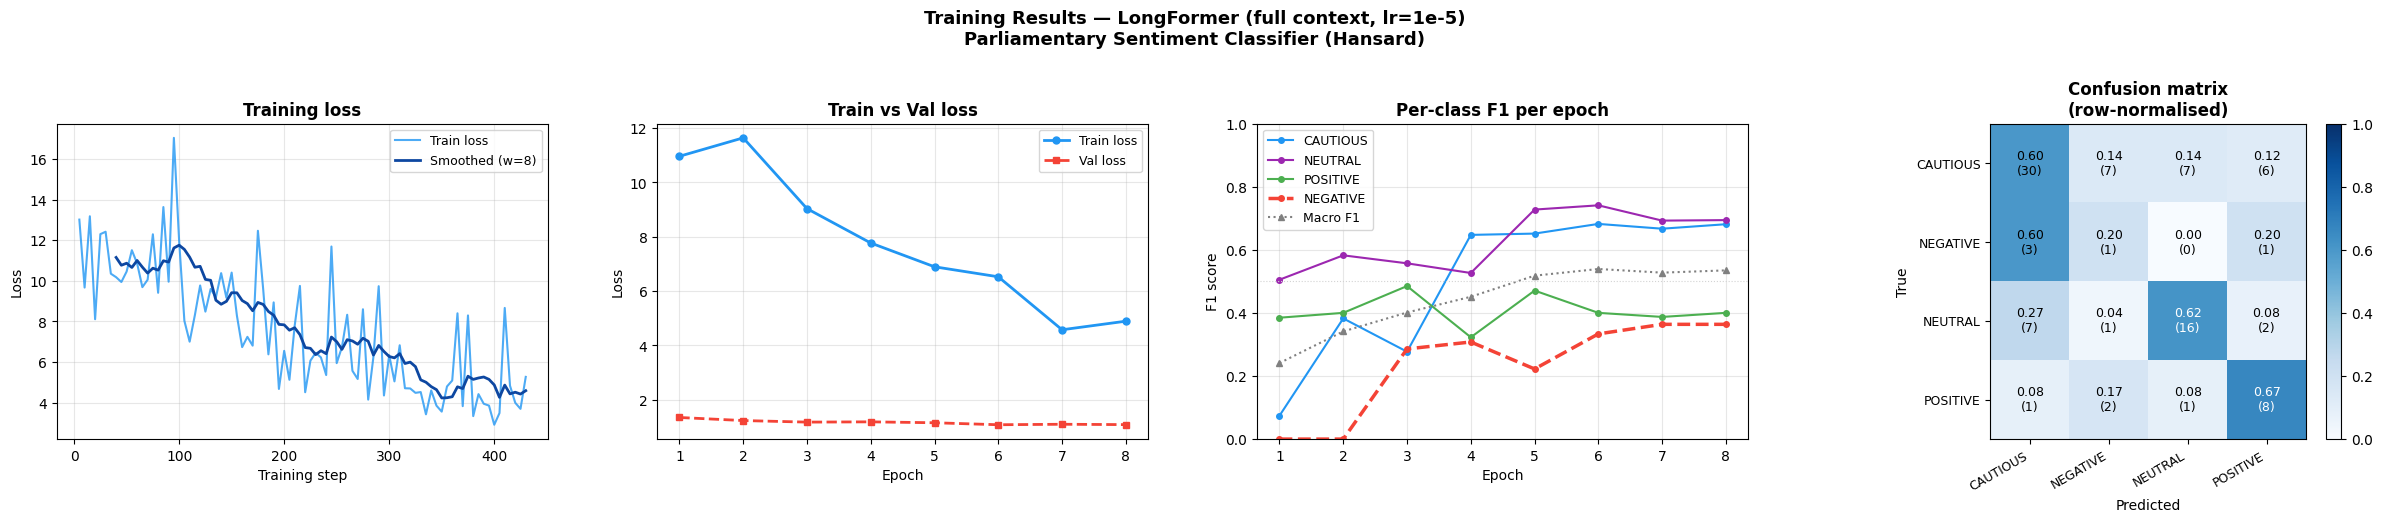

Plots saved to ./longformer_training_plots.png


In [ ]:
# Evaluate on test set with argmax (baseline — before threshold tuning)
print('Evaluating on held-out test set (argmax baseline)...')
test_output_lf = trainer_lf.predict(test_hf)
test_logits_lf = test_output_lf.predictions        # raw logits, shape (N_test, 4)
test_probs_lf  = torch.softmax(
    torch.tensor(test_logits_lf), dim=-1
).numpy()                                           # shape (N_test, 4)
test_preds_lf  = np.argmax(test_probs_lf, axis=-1)
test_labels_lf = test_output_lf.label_ids

print('\nBaseline classification report (argmax):')
print(classification_report(
    test_labels_lf, test_preds_lf,
    target_names=le.classes_, digits=3, zero_division=0
))

plot_training_curves(
    trainer       = trainer_lf,
    label_encoder = le,
    test_labels   = test_labels_lf,
    test_preds    = test_preds_lf,
    output_dir    = '.',
    model_name    = 'LongFormer (full context, lr=1e-5)'
)

## 9. Threshold tuning on validation set

In [ ]:
# ── Get validation set probabilities ─────────────────────────────────
print('Extracting validation set probabilities...')
val_output_lf = trainer_lf.predict(val_hf)
val_probs     = torch.softmax(
    torch.tensor(val_output_lf.predictions), dim=-1
).numpy()                                           # shape (N_val, 4)
val_labels_lf = val_output_lf.label_ids

# Baseline on val set
baseline_val_preds = np.argmax(val_probs, axis=-1)
baseline_val_f1    = f1_score(val_labels_lf, baseline_val_preds,
                               average='macro', zero_division=0)
print(f'\nBaseline val macro F1 (argmax): {baseline_val_f1:.4f}')
print('\nBaseline val classification report:')
print(classification_report(
    val_labels_lf, baseline_val_preds,
    target_names=le.classes_, digits=3, zero_division=0
))

Extracting validation set probabilities...



Baseline val macro F1 (argmax): 0.5390

Baseline val classification report:
              precision    recall  f1-score   support

    CAUTIOUS      0.789     0.600     0.682        50
    NEGATIVE      0.286     0.400     0.333         5
     NEUTRAL      0.714     0.769     0.741        26
    POSITIVE      0.316     0.545     0.400        11

    accuracy                          0.630        92
   macro avg      0.526     0.579     0.539        92
weighted avg      0.684     0.630     0.646        92



In [ ]:
# ── Grid search over per-class thresholds ────────────────────────────
def predict_with_thresholds(probs, thresholds):
    """
    For each sample, predict the class with the highest probability
    that also exceeds its per-class threshold.
    Falls back to argmax if no class clears its threshold.

    Args:
        probs      : np.ndarray of shape (N, n_classes), softmax probabilities
        thresholds : list of floats, one per class in le.classes_ order

    Returns:
        np.ndarray of shape (N,), predicted class indices
    """
    preds = []
    for prob_row in probs:
        above = [
            i for i, (p, t) in enumerate(zip(prob_row, thresholds))
            if p >= t
        ]
        if above:
            preds.append(above[np.argmax([prob_row[i] for i in above])])
        else:
            preds.append(np.argmax(prob_row))    # fallback: argmax
    return np.array(preds)


# Search one class at a time, holding best thresholds fixed
best_thresholds = [0.25] * len(le.classes_)      # uniform start for 4 classes
best_val_f1     = baseline_val_f1

print('Searching thresholds...')
print(f'  Class order: {list(le.classes_)}')
print()

for cls_idx in range(len(le.classes_)):
    cls_name = le.classes_[cls_idx]
    for threshold in np.arange(0.10, 0.85, 0.05):
        candidate = best_thresholds.copy()
        candidate[cls_idx] = round(float(threshold), 2)

        preds = predict_with_thresholds(val_probs, candidate)
        score = f1_score(val_labels_lf, preds,
                         average='macro', zero_division=0)

        if score > best_val_f1:
            best_val_f1              = score
            best_thresholds[cls_idx] = round(float(threshold), 2)
            print(f'  Improved: {cls_name} threshold={threshold:.2f} '
                  f'→ val macro F1={score:.4f}')

print(f'\nFinal thresholds : {dict(zip(le.classes_, best_thresholds))}')
print(f'Tuned val macro F1 : {best_val_f1:.4f}  '
      f'(baseline: {baseline_val_f1:.4f}, '
      f'delta: {best_val_f1 - baseline_val_f1:+.4f})')

Searching thresholds...
  Class order: ['CAUTIOUS', 'NEGATIVE', 'NEUTRAL', 'POSITIVE']

  Improved: NEGATIVE threshold=0.30 → val macro F1=0.5446

Final thresholds : {'CAUTIOUS': 0.25, 'NEGATIVE': 0.3, 'NEUTRAL': 0.25, 'POSITIVE': 0.25}
Tuned val macro F1 : 0.5446  (baseline: 0.5390, delta: +0.0057)


In [ ]:
# ── Evaluate tuned thresholds on test set ────────────────────────────
tuned_test_preds = predict_with_thresholds(test_probs_lf, best_thresholds)

print('Tuned threshold — test set classification report:')
print(classification_report(
    test_labels_lf, tuned_test_preds,
    target_names=le.classes_, digits=3, zero_division=0
))

# Side-by-side summary
baseline_macro = f1_score(test_labels_lf, test_preds_lf,
                           average='macro', zero_division=0)
tuned_macro    = f1_score(test_labels_lf, tuned_test_preds,
                           average='macro', zero_division=0)
print(f'\nTest macro F1 — argmax   : {baseline_macro:.4f}')
print(f'Test macro F1 — tuned    : {tuned_macro:.4f}')
print(f'Delta                    : {tuned_macro - baseline_macro:+.4f}')

Tuned threshold — test set classification report:
              precision    recall  f1-score   support

    CAUTIOUS      0.732     0.600     0.659        50
    NEGATIVE      0.091     0.200     0.125         5
     NEUTRAL      0.667     0.615     0.640        26
    POSITIVE      0.471     0.667     0.552        12

    accuracy                          0.591        93
   macro avg      0.490     0.521     0.494        93
weighted avg      0.645     0.591     0.611        93


Test macro F1 — argmax   : 0.4940
Test macro F1 — tuned    : 0.4940
Delta                    : +0.0000


## 10. Save model, tokenizer, thresholds, splits

In [ ]:
os.makedirs('./plp_checkpoint', exist_ok=True)

# Model and tokenizer
model_lf.save_pretrained('./plp_checkpoint/longformer_option_c')
tokenizer_lf.save_pretrained('./plp_checkpoint/longformer_option_c')
print('✓ LongFormer model and tokenizer saved')

# Label encoder
with open('./plp_checkpoint/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print('✓ Label encoder saved')

# Class weights tensor
torch.save(class_weights_tensor.cpu(),
           './plp_checkpoint/class_weights_tensor.pt')
print('✓ Class weights tensor saved')

# Tuned thresholds — save as pickle so inference section can reload them
with open('./plp_checkpoint/best_thresholds.pkl', 'wb') as f:
    pickle.dump(best_thresholds, f)
print(f'✓ Thresholds saved: {dict(zip(le.classes_, best_thresholds))}')

# Train/val/test splits
train_df.to_csv('./plp_checkpoint/split_train.csv', index=False)
val_df.to_csv('./plp_checkpoint/split_val.csv',     index=False)
test_df.to_csv('./plp_checkpoint/split_test.csv',   index=False)
print('✓ Splits saved')

# Training results for report
results = {
    'test_preds_argmax': test_preds_lf,
    'test_preds_tuned':  tuned_test_preds,
    'test_labels':       test_labels_lf,
    'best_thresholds':   best_thresholds,
    'log_history':       trainer_lf.state.log_history,
    'best_checkpoint':   trainer_lf.state.best_model_checkpoint,
    'best_metric':       trainer_lf.state.best_metric,
}
with open('./plp_checkpoint/longformer_results_tuned.pkl', 'wb') as f:
    pickle.dump(results, f)
print('✓ Training results saved')

print('\nCheckpoint directory contents:')
for fname in sorted(os.listdir('./plp_checkpoint')):
    size = os.path.getsize(f'./plp_checkpoint/{fname}')
    print(f'  {fname:<45} {size/1024/1024:.1f} MB')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ LongFormer model and tokenizer saved
✓ Label encoder saved
✓ Class weights tensor saved
✓ Thresholds saved: {'CAUTIOUS': 0.25, 'NEGATIVE': 0.3, 'NEUTRAL': 0.25, 'POSITIVE': 0.25}
✓ Splits saved
✓ Training results saved

Checkpoint directory contents:
  best_thresholds.pkl                           0.0 MB
  class_weights_tensor.pt                       0.0 MB
  label_encoder.pkl                             0.0 MB
  longformer_option_c                           0.0 MB
  longformer_results_tuned.pkl                  0.0 MB
  split_test.csv                                0.2 MB
  split_train.csv                               0.9 MB
  split_val.csv                                 0.2 MB


---
# RESTART FROM HERE
Run the cell below to restore everything from Drive, then continue.

In [ ]:
import os
import pickle
import shutil
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from google.colab import drive
from transformers import (
    LongformerTokenizer,
    LongformerForSequenceClassification
)
from datasets import Dataset
from sklearn.metrics import f1_score, classification_report

# Mount Drive and restore checkpoint
drive.mount('/content/drive')

src = '/content/drive/MyDrive/PLP_Project/plp_checkpoint'
dst = './plp_checkpoint'

def ignore_gdrive_files(directory, contents):
    return [f for f in contents
            if f.endswith(('.gsheet', '.gdoc', '.gslides', '.gform'))]

if not os.path.exists(dst):
    print(f'Copying checkpoint from Drive...')
    shutil.copytree(src, dst, ignore=ignore_gdrive_files)
    print('✓ Checkpoint restored')
else:
    print('✓ Local checkpoint already exists')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✓ Device: {device}')

# Label encoder
with open('./plp_checkpoint/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)
print(f'✓ Label encoder: {le.classes_}')

# Tuned thresholds
with open('./plp_checkpoint/best_thresholds.pkl', 'rb') as f:
    best_thresholds = pickle.load(f)
print(f'✓ Thresholds: {dict(zip(le.classes_, best_thresholds))}')

# LongFormer model and tokenizer
tokenizer_lf = LongformerTokenizer.from_pretrained(
    './plp_checkpoint/longformer_option_c'
)
model_lf = LongformerForSequenceClassification.from_pretrained(
    './plp_checkpoint/longformer_option_c'
).to(device)
model_lf.eval()
print('✓ LongFormer loaded and set to eval mode')
print(f'  Parameters   : {sum(p.numel() for p in model_lf.parameters()):,}')
print(f'  Labels       : {list(le.classes_)}')

# SENTIMENT_CLASSES in label encoder order — used throughout inference
SENTIMENT_CLASSES = list(le.classes_)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Local checkpoint already exists
✓ Device: cuda
✓ Label encoder: ['CAUTIOUS' 'NEGATIVE' 'NEUTRAL' 'POSITIVE']
✓ Thresholds: {'CAUTIOUS': 0.25, 'NEGATIVE': 0.3, 'NEUTRAL': 0.25, 'POSITIVE': 0.25}


Loading weights:   0%|          | 0/273 [00:00<?, ?it/s]

✓ LongFormer loaded and set to eval mode
  Parameters   : 148,662,532
  Labels       : ['CAUTIOUS', 'NEGATIVE', 'NEUTRAL', 'POSITIVE']


## 11. Load inference data & assign speaker tiers

In [ ]:
os.chdir('/content/drive/MyDrive/PLP_Project/plp_checkpoint')

inference_df = pd.read_csv('inference_set.csv')
inference_df.drop(columns=['_key'], inplace=True, errors='ignore')

print(f'Inference set shape: {inference_df.shape}')
inference_df.info()
inference_df.head()

Inference set shape: (6774, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6774 entries, 0 to 6773
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   sittingDate  6774 non-null   object
 1   title        6774 non-null   object
 2   speaker      6774 non-null   object
 3   segment_no   6774 non-null   int64 
 4   speech_text  6774 non-null   object
 5   id           6774 non-null   object
dtypes: int64(1), object(5)
memory usage: 317.7+ KB


,sittingDate,title,speaker,segment_no,speech_text,id
0,22-09-2025,Election of Deputy Speakers,Mr Zaqy Mohamad,1,"Mr Speaker, I propose that Mr Christopher de S...",ST1
1,22-09-2025,Election of Deputy Speakers,Ms Yeo Wan Ling,2,"Mr Speaker, I support the proposal.",ST2
2,22-09-2025,Retirement of Clerk of Parliament,Ms Indranee Rajah,1,"Mr Speaker, please allow me, on behalf of Memb...",ST3
3,22-09-2025,Singapore's Support in Humanitarian Aid for Cr...,Mr Vikram Nair,1,asked the Minister for Foreign Affairs with co...,ST4
4,22-09-2025,Singapore's Support in Humanitarian Aid for Cr...,Mr Kwek Hian Chuan Henry,4,asked the Minister for Foreign Affairs (a) whe...,ST7


In [ ]:
# ── Speaker tier assignment ───────────────────────────────────────────
# Based on 2025 Cabinet Appointments (Annex A)

pm_dpm = {'Mr Lawrence Wong', 'Mr Gan Kim Yong'}

ministers = {
    'Mr Chan Chun Sing', 'Mr Ong Ye Kung', 'Mr Chee Hong Tat',
    'Mr Desmond Lee', 'Dr Vivian Balakrishnan', 'Mr K Shanmugam',
    'Mr Edwin Tong Chun Fai', 'Dr Tan See Leng', 'Mr Masagos Zulkifli B M M',
    'Ms Grace Fu Hai Yien', 'Mrs Josephine Teo', 'Ms Indranee Rajah',
    'Mr Jeffrey Siow', 'Mr David Neo',
}

sms = {
    'Dr Koh Poh Koon', 'Mr Murali Pillai', 'Ms Sun Xueling',
    'Ms Sim Ann', 'Mr Zaqy Mohamad', 'Ms Goh Hanyan',
    'Mr Tan Kiat How', 'Ms Rahayu Mahzam',
}

mos = {
    'Mr Desmond Tan', 'Mr Baey Yam Keng', 'Mr Alvin Tan',
    'Ms Low Yen Ling', 'Ms Gan Siow Huang', 'Mr Dinesh Vasu Dash',
    'Mr Goh Pei Ming', 'Dr Janil Puthucheary', 'Mr Zhulkarnain Abdul Rahim',
    'Mr Shawn Huang Wei Zhong', 'Assoc Prof Dr Muhammad Faishal Ibrahim',
    'Mr Eric Chua',
}

sps = {'Ms Jasmin Lau', 'Dr Syed Harun Alhabsyi'}

tier1_speakers = pm_dpm | ministers | sms | mos | sps

tier3_speakers = {
    'Mr Pritam Singh', 'Ms Sylvia Lim', 'Mr Gerald Giam Yean Song',
    'Mr Dennis Tan Lip Fong', 'Mr Chua Kheng Wee Louis', 'Ms He Ting Ru',
    'Assoc Prof Jamus Jerome Lim', 'Mr Kenneth Tiong Boon Kiat',
    'Mr Low Wu Yang Andre', 'Ms Eileen Chong Pei Shan', 'Mr Fadli Fawzi',
    'Mr Leong Mun Wai', 'Ms Hazel Poa',
}

tier4_speakers = {
    'Ms Kuah Boon Theng', 'Assoc Prof Kenneth Goh', 'Mr Sanjeev Kumar Tiwari',
    'Prof Kenneth Poon', 'Mr Mark Lee', 'Dr Haresh Singaraju',
    'Assoc Prof Terence Ho', 'Dr Neo Kok Beng', 'Mr Azhar Othman',
}

procedural_speakers = {
    'Mr Deputy Speaker', 'Mr Speaker', 'Madam Speaker',
    'Mr Chairman', 'Madam Chairman',
}

def assign_tier(speaker):
    if speaker in tier1_speakers:      return 'Tier1'
    elif speaker in tier3_speakers:    return 'Tier3'
    elif speaker in tier4_speakers:    return 'Tier4'
    elif speaker in procedural_speakers: return 'Procedural'
    else:                              return 'Tier2'  # PAP backbench default

def get_role_weight(speaker_tier):
    weights = {'Tier1': 1.25, 'Tier2': 1.00,
               'Tier3': 0.75, 'Tier4': 0.50, 'Procedural': 0.50}
    return weights.get(speaker_tier, 1.00)

inference_df['speaker_tier'] = inference_df['speaker'].apply(assign_tier)
inference_df['role_weight']  = inference_df['speaker_tier'].apply(get_role_weight)

print('Speaker tier distribution:')
print(inference_df['speaker_tier'].value_counts())
print('\nTop 20 Tier2-defaulted speakers (verify none are office holders):')
print(inference_df[inference_df['speaker_tier'] == 'Tier2']['speaker']
      .value_counts().head(20))

Speaker tier distribution:
speaker_tier
Tier1         3101
Tier2         2393
Tier3         1039
Procedural     184
Tier4           57
Name: count, dtype: int64

Top 20 Tier2-defaulted speakers (verify none are office holders):
speaker
Mr Abdul Muhaimin Abdul Malik    124
Mr Yip Hon Weng                  112
Mr David Hoe                     104
Mr Cai Yinzhou                    98
Ms Valerie Lee                    90
Ms Elysa Chen                     88
Dr Charlene Chen                  78
Mr Ng Shi Xuan                    76
Mr Patrick Tay Teck Guan          71
Dr Hamid Razak                    70
Mr Shawn Loh                      64
Mr Lee Hong Chuang                61
Dr Choo Pei Ling                  61
Mr Melvin Yong Yik Chye           59
Ms Poh Li San                     58
Dr Wan Rizal                      58
Mr Foo Cexiang                    58
Mr Saktiandi Supaat               57
Ms Yeo Wan Ling                   53
Ms Hany Soh                       51
Name: count, dtype: int6

## 12. Tokenise inference set

In [ ]:
MAX_LEN_LF = 4096

def tokenize_longformer_infer(batch):
    """
    Inference tokenizer — input column is 'text' (renamed from speech_text).
    Identical logic to training tokenizer.
    """
    encoded = tokenizer_lf(
        batch['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN_LF,
        return_tensors=None
    )
    encoded['global_attention_mask'] = [
        [1] + [0] * (MAX_LEN_LF - 1)
        for _ in encoded['input_ids']
    ]
    return encoded

infer_hf = Dataset.from_pandas(
    inference_df[['speech_text']]
    .rename(columns={'speech_text': 'text'})
    .reset_index(drop=True)
)

print(f'Tokenizing {len(infer_hf)} inference turns...')
print('Expected time on T4: ~8-12 minutes at MAX_LEN=4096')

infer_hf = infer_hf.map(tokenize_longformer_infer, batched=True, batch_size=8)
infer_hf.set_format(
    'torch',
    columns=['input_ids', 'attention_mask', 'global_attention_mask']
)

print(f'Inference dataset ready: {len(infer_hf)} samples')
print(f'Sample shape: {infer_hf[0]["input_ids"].shape}')

Tokenizing 6774 inference turns...
Expected time on T4: ~8-12 minutes at MAX_LEN=4096


Map:   0%|          | 0/6774 [00:00<?, ? examples/s]

Inference dataset ready: 6774 samples
Sample shape: torch.Size([4096])


## 13. Run inference with tuned thresholds

In [ ]:
from torch.utils.data import DataLoader
from tqdm import tqdm

model_lf.eval()
all_logits = []

infer_loader = DataLoader(infer_hf, batch_size=8, shuffle=False)

print(f'Running inference on {len(infer_hf)} turns...')
print(f'Batches: {len(infer_loader)}')

with torch.no_grad():
    for batch in tqdm(infer_loader, desc='Inferring'):
        input_ids             = batch['input_ids'].to(device)
        attention_mask        = batch['attention_mask'].to(device)
        global_attention_mask = batch['global_attention_mask'].to(device)

        outputs = model_lf(
            input_ids             = input_ids,
            attention_mask        = attention_mask,
            global_attention_mask = global_attention_mask
        )
        all_logits.append(outputs.logits.cpu())

all_logits = torch.cat(all_logits, dim=0)             # shape: (N, 4)
all_probs  = torch.softmax(all_logits, dim=-1).numpy() # shape: (N, 4)

print(f'\nInference complete.')
print(f'Logits shape : {all_logits.shape}')
print(f'Probs shape  : {all_probs.shape}')

Running inference on 6774 turns...
Batches: 847


Inferring: 100%|██████████| 847/847 [50:51<00:00,  3.60s/it]


Inference complete.
Logits shape : torch.Size([6774, 4])
Probs shape  : (6774, 4)


In [ ]:
# ── Apply tuned thresholds ────────────────────────────────────────────
def predict_with_thresholds(probs, thresholds):
    """
    For each sample, predict the class with the highest probability
    that also exceeds its per-class threshold.
    Falls back to argmax if no class clears its threshold.
    """
    preds = []
    for prob_row in probs:
        above = [
            i for i, (p, t) in enumerate(zip(prob_row, thresholds))
            if p >= t
        ]
        if above:
            preds.append(above[np.argmax([prob_row[i] for i in above])])
        else:
            preds.append(np.argmax(prob_row))
    return np.array(preds)

all_preds_argmax = np.argmax(all_probs, axis=-1)
all_preds_tuned  = predict_with_thresholds(all_probs, best_thresholds)

# Distribution comparison
label_map = {i: cls for i, cls in enumerate(le.classes_)}
print(f'Thresholds applied: {dict(zip(le.classes_, best_thresholds))}')
print(f"\n{'Class':<12} {'Argmax':>8} {'Tuned':>8} {'Diff':>8}")
print('-' * 40)
for cls_idx, cls_name in enumerate(le.classes_):
    old_n = (all_preds_argmax == cls_idx).sum()
    new_n = (all_preds_tuned  == cls_idx).sum()
    print(f'{cls_name:<12} {old_n:>8} {new_n:>8} {new_n - old_n:>+8}')

# Write tuned predictions and per-class probabilities back to dataframe
inference_df['predicted_label']  = [label_map[p] for p in all_preds_tuned]
inference_df['confidence_score'] = all_probs.max(axis=1)
for i, cls in enumerate(le.classes_):
    inference_df[f'prob_{cls.lower()}'] = all_probs[:, i]

print('\nPredicted label distribution (tuned):')
print(inference_df['predicted_label'].value_counts())
print('\nConfidence score stats:')
print(inference_df['confidence_score'].describe().round(3))

Thresholds applied: {'CAUTIOUS': 0.25, 'NEGATIVE': 0.3, 'NEUTRAL': 0.25, 'POSITIVE': 0.25}

Class          Argmax    Tuned     Diff
----------------------------------------
CAUTIOUS         2696     2696       +0
NEGATIVE          290      290       +0
NEUTRAL          2918     2918       +0
POSITIVE          870      870       +0

Predicted label distribution (tuned):
predicted_label
NEUTRAL     2918
CAUTIOUS    2696
POSITIVE     870
NEGATIVE     290
Name: count, dtype: int64

Confidence score stats:
count    6774.000
mean        0.645
std         0.127
min         0.288
25%         0.545
50%         0.662
75%         0.749
max         0.895
Name: confidence_score, dtype: float64


## 14. Combine with manual labels & deduplicate

In [ ]:
# ── Prepare manual labelled set ───────────────────────────────────────
labelled_df = pd.read_csv('final_train_weights.csv')
labelled_df = labelled_df.rename(columns={'sentiment_label': 'predicted_label'})

# Use sample_weight as confidence_score — encodes annotation certainty:
# unanimous/majority=1.0, HIGH=0.9, MEDIUM=0.7, LOW=0.4
labelled_df['confidence_score'] = labelled_df['sample_weight']
labelled_df['source']           = 'manual_label'

# Assign tier and role weight to labelled set
labelled_df['speaker_tier'] = labelled_df['speaker'].apply(assign_tier)
labelled_df['role_weight']  = labelled_df['speaker_tier'].apply(get_role_weight)

# One-hot probability columns using firm manual label
for cls in SENTIMENT_CLASSES:
    labelled_df[f'prob_{cls.lower()}'] = (
        labelled_df['predicted_label'] == cls
    ).astype(float)

print(f'Labelled set: {len(labelled_df)} turns')
print(labelled_df['predicted_label'].value_counts())

# ── Tag inference set ─────────────────────────────────────────────────
inference_df['source'] = 'model_prediction'

# ── Combine and deduplicate ───────────────────────────────────────────
COMMON_COLS = [
    'sittingDate', 'title', 'speaker', 'speaker_tier', 'role_weight',
    'speech_text', 'predicted_label', 'confidence_score',
    'prob_cautious', 'prob_negative', 'prob_neutral', 'prob_positive',
    'source'
]

# Verify columns before combining
missing = False
for col in COMMON_COLS:
    if col not in inference_df.columns:
        print(f'MISSING from inference_df : {col}')
        missing = True
    if col not in labelled_df.columns:
        print(f'MISSING from labelled_df  : {col}')
        missing = True
if not missing:
    print('✓ All columns present in both DataFrames')

# Manual labels first — they win deduplication
# 'manual_label' sorts before 'model_prediction' alphabetically
full_corpus_df = pd.concat(
    [labelled_df[COMMON_COLS], inference_df[COMMON_COLS]],
    ignore_index=True
)
full_corpus_df = full_corpus_df.sort_values('source').drop_duplicates(
    subset=['sittingDate', 'title', 'speaker', 'speech_text'],
    keep='first'
)

print(f'\nCombined corpus:')
print(f"  Manual labels     : {(full_corpus_df['source'] == 'manual_label').sum()}")
print(f"  Model predictions : {(full_corpus_df['source'] == 'model_prediction').sum()}")
print(f'  Total turns       : {len(full_corpus_df)}')
print(f"  Duplicates        : "
      f"{full_corpus_df.duplicated(subset=['sittingDate','title','speaker','speech_text']).sum()} "
      f'(should be 0)')

Labelled set: 615 turns
predicted_label
CAUTIOUS    334
NEUTRAL     172
POSITIVE     76
NEGATIVE     33
Name: count, dtype: int64
✓ All columns present in both DataFrames

Combined corpus:
  Manual labels     : 615
  Model predictions : 6767
  Total turns       : 7382
  Duplicates        : 0 (should be 0)


## 15. Aggregate topic sentiments

In [ ]:
def aggregate_topic_sentiment(topic_df):
    """
    Role-weighted aggregation of turn-level predictions
    into a single topic-level sentiment.

    Weighted score per class = sum(role_weight * confidence_score)
    for all turns predicted as that class.
    Normalised by total role weight across all turns in the topic.
    """
    if len(topic_df) == 0:
        return {
            'topic_sentiment':   'NEUTRAL',
            'num_turns':         0,
            'total_role_weight': 0.0,
            **{f'weighted_{cls.lower()}': 0.0 for cls in SENTIMENT_CLASSES}
        }

    weighted_scores = {cls: 0.0 for cls in SENTIMENT_CLASSES}
    total_weight    = 0.0

    for _, turn in topic_df.iterrows():
        role_weight = turn['role_weight']
        pred_label  = turn['predicted_label']
        conf_score  = float(turn['confidence_score'])

        weighted_scores[pred_label] += role_weight * conf_score
        total_weight                += role_weight

    normalised = {
        cls: score / total_weight
        for cls, score in weighted_scores.items()
    } if total_weight > 0 else {cls: 0.0 for cls in SENTIMENT_CLASSES}

    topic_sentiment = max(normalised, key=normalised.get)

    return {
        'topic_sentiment':   topic_sentiment,
        'num_turns':         len(topic_df),
        'total_role_weight': round(total_weight, 3),
        **{f'weighted_{cls.lower()}': round(v, 4)
           for cls, v in normalised.items()}
    }


print('Aggregating topic sentiments...')

topic_results = []
for (sitting_date, title), group in full_corpus_df.groupby(
    ['sittingDate', 'title'], sort=False
):
    result = aggregate_topic_sentiment(group)
    topic_results.append({'sittingDate': sitting_date, 'title': title, **result})

topic_df_complete = pd.DataFrame(topic_results)

print(f'Total debate topics : {len(topic_df_complete)}')
print(f'\nTopic sentiment distribution:')
print(topic_df_complete['topic_sentiment'].value_counts())

Aggregating topic sentiments...
Total debate topics : 2493

Topic sentiment distribution:
topic_sentiment
NEUTRAL     1648
CAUTIOUS     507
POSITIVE     329
NEGATIVE       9
Name: count, dtype: int64


## 16. Save outputs

In [ ]:
topic_df_complete.to_csv('hansard_topic_sentiments_complete_threshold_tuning.csv',  index=False)
full_corpus_df.to_csv('hansard_turn_sentiments_complete_threshold_tuning.csv', index=False)

print('✓ Saved:')
print(f'  Turn-level  : hansard_turn_sentiments_complete_threshold_tuning.csv  ({len(full_corpus_df)} rows)')
print(f'  Topic-level : hansard_topic_sentiments_complete_threshold_tuning.csv ({len(topic_df_complete)} rows)')

✓ Saved:
  Turn-level  : hansard_turn_sentiments_complete_threshold_tuning.csv  (7382 rows)
  Topic-level : hansard_topic_sentiments_complete_threshold_tuning.csv (2493 rows)


## 17. Exploratory analysis

In [ ]:
# ── Sitting-level sentiment profile ──────────────────────────────────
sitting_profile = topic_df_complete.groupby('sittingDate').agg(
    total_topics = ('topic_sentiment', 'count'),
    pct_cautious = ('topic_sentiment', lambda x: (x == 'CAUTIOUS').mean() * 100),
    pct_negative = ('topic_sentiment', lambda x: (x == 'NEGATIVE').mean() * 100),
    pct_neutral  = ('topic_sentiment', lambda x: (x == 'NEUTRAL').mean()  * 100),
    pct_positive = ('topic_sentiment', lambda x: (x == 'POSITIVE').mean() * 100)
).round(2)

sitting_profile = sitting_profile.sort_values('pct_positive', ascending=False)
print('Sentiment profile by sitting:')
print(sitting_profile.to_string())

Sentiment profile by sitting:
             total_topics  pct_cautious  pct_negative  pct_neutral  pct_positive
sittingDate                                                                     
25-09-2025            127         23.62          0.00        55.12         21.26
26-09-2025            112         19.64          0.00        60.71         19.64
12-02-2026             83         18.07          0.00        63.86         18.07
15-10-2025            143         16.78          0.00        67.13         16.08
13-01-2026            122         19.67          0.00        64.75         15.57
23-09-2025            125         21.60          0.00        63.20         15.20
03-02-2026            165         21.82          0.61        63.64         13.94
24-09-2025            142         16.90          0.00        69.72         13.38
14-10-2025            152         24.34          0.66        61.84         13.16
04-02-2026            146         16.44          0.00        70.55         13.0

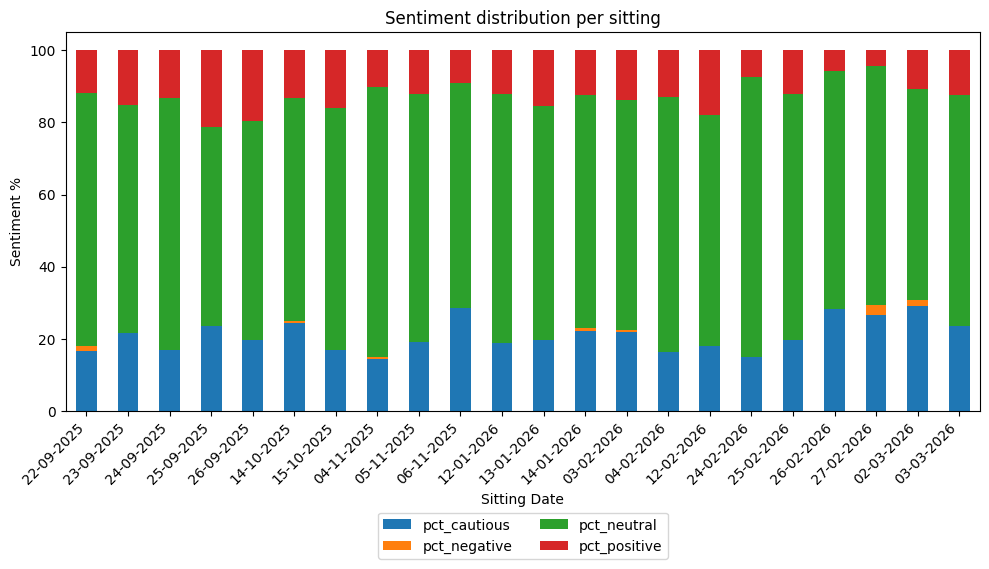

In [ ]:
# ── Stacked bar chart ─────────────────────────────────────────────────
import matplotlib.pyplot as plt

plot_df = sitting_profile[[
    'pct_cautious', 'pct_negative', 'pct_neutral', 'pct_positive'
]].copy().reset_index()

plot_df['sittingDate'] = pd.to_datetime(
    plot_df['sittingDate'], format='%d-%m-%Y'
)
plot_df = plot_df.set_index('sittingDate').sort_index()

ax = plot_df.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.xlabel('Sitting Date')
plt.ylabel('Sentiment %')
plt.title('Sentiment distribution per sitting')
plt.legend(bbox_to_anchor=(0.5, -0.25), loc='upper center', ncol=2)

labels = [item.get_text() for item in ax.get_xticklabels()]
formatted_labels = [
    pd.to_datetime(label).strftime('%d-%m-%Y') for label in labels
]
ax.set_xticklabels(formatted_labels, rotation=45, ha='right')
plt.tight_layout()
plt.savefig('sitting_sentiment_profile.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Spotlight: two contrasting sittings ──────────────────────────────
SITTING_A = '23-09-2025'   # adjust to a sitting you know well
SITTING_B = '27-02-2026'   # adjust to a contrasting sitting

def sitting_summary(sitting_date, label):
    subset = topic_df_complete[
        topic_df_complete['sittingDate'] == sitting_date
    ]
    print(f'\n{label} ({sitting_date}) — {len(subset)} topics:')
    print(subset['topic_sentiment'].value_counts().to_string())

    print('\nTop CAUTIOUS topics:')
    cautious = subset[subset['topic_sentiment'] == 'CAUTIOUS']\
        .nlargest(3, 'weighted_cautious')
    for _, r in cautious.iterrows():
        print(f"  [{r['weighted_cautious']:.3f}] {r['title'][:70]}")

    print('\nTop NEGATIVE topics:')
    negative = subset[subset['topic_sentiment'] == 'NEGATIVE']\
        .nlargest(3, 'weighted_negative')
    for _, r in negative.iterrows():
        print(f"  [{r['weighted_negative']:.3f}] {r['title'][:70]}")

sitting_summary(SITTING_A, 'Sitting A')
sitting_summary(SITTING_B, 'Sitting B')


Sitting A (23-09-2025) — 125 topics:
topic_sentiment
NEUTRAL     79
CAUTIOUS    27
POSITIVE    19

Top CAUTIOUS topics:
  [0.789] Improving Recycling Rates within Businesses and Residential Areas and 
  [0.663] Disclosing Emissions and Carbon Tax Relief of Individual Companies and
  [0.532] Implementation of New Guidelines to Provide Clarity in Job Postings on

Top NEGATIVE topics:

Sitting B (27-02-2026) — 68 topics:
topic_sentiment
NEUTRAL     45
CAUTIOUS    18
POSITIVE     3
NEGATIVE     2

Top CAUTIOUS topics:
  [0.900] Committee of Supply – Head J (Ministry of Defence)
  [0.850] Committee of Supply – Head N (Ministry of Foreign Affairs)
  [0.703] Clarification by Senior Minister of State for Health

Top NEGATIVE topics:
  [0.900] Committee of Supply – Head R (Ministry of Law)
  [0.268] Committee of Supply â Head F (Parliament) 


In [ ]:
# Inspect the NEGATIVE topics in the 27-02-2026 sitting
sitting_neg = topic_df_complete[
    (topic_df_complete['sittingDate'] == '27-02-2026') &
    (topic_df_complete['topic_sentiment'] == 'NEGATIVE')
].sort_values('weighted_negative', ascending=False)

print(f"NEGATIVE topics in 27-02-2026: {len(sitting_neg)}")
print()
for _, row in sitting_neg.iterrows():
    print(f"Title       : {row['title']}")
    print(f"Turns       : {row['num_turns']}")
    print(f"weighted_neg: {row['weighted_negative']:.4f}")
    print()

# Now pull the actual turns that were predicted NEGATIVE for each topic
for _, topic_row in sitting_neg.iterrows():
    turns = full_corpus_df[
        (full_corpus_df['sittingDate'] == '27-02-2026') &
        (full_corpus_df['title'] == topic_row['title']) &
        (full_corpus_df['predicted_label'] == 'NEGATIVE')
    ]
    print(f"=== {topic_row['title']} ===")
    for _, turn in turns.iterrows():
        print(f"  Speaker    : {turn['speaker']} ({turn['speaker_tier']})")
        print(f"  Confidence : {turn['confidence_score']:.3f}")
        print(f"  Prob dist  : CAU={turn['prob_cautious']:.3f} "
              f"NEG={turn['prob_negative']:.3f} "
              f"NEU={turn['prob_neutral']:.3f} "
              f"POS={turn['prob_positive']:.3f}")
        print(f"  Text       : {turn['speech_text'][:300]}")
        print()

NEGATIVE topics in 27-02-2026: 2

Title       : Committee of Supply – Head R (Ministry of Law)
Turns       : 1
weighted_neg: 0.9000

Title       : Committee of Supply â Head F (Parliament) 
Turns       : 5
weighted_neg: 0.2677

=== Committee of Supply – Head R (Ministry of Law) ===
  Speaker    : Mr Gabriel Lam (Tier2)
  Confidence : 0.900
  Prob dist  : CAU=0.000 NEG=1.000 NEU=0.000 POS=0.000
  Text       : Mr Chairman, in previous debates, the Ministry said it was studying reforms to strengthen civil enforcement, including greater powers to identify the assets of judgment debtors and stronger deterrence against non-compliance with Court orders. These reforms are necessary. For many Singaporeans, espec

=== Committee of Supply â Head F (Parliament)  ===
  Speaker    : Ms Indranee Rajah (Tier1)
  Confidence : 0.679
  Prob dist  : CAU=0.133 NEG=0.679 NEU=0.037 POS=0.151
  Text       : Mr Chairman, the gist of this cut was strengthening Parliamentary democracy and safeguarding democr

In [ ]:
# Confidence distribution of all NEGATIVE predictions across the full corpus
neg_turns = full_corpus_df[full_corpus_df['predicted_label'] == 'NEGATIVE']

print(f"Total NEGATIVE predicted turns: {len(neg_turns)}")
print()
print("Confidence score distribution:")
print(neg_turns['confidence_score'].describe().round(3))
print()

# Flag low-confidence NEGATIVE predictions specifically
low_conf_neg = neg_turns[neg_turns['confidence_score'] < 0.50]
print(f"Low-confidence NEGATIVE turns (prob < 0.50): {len(low_conf_neg)}")
print()

# Show their probability distributions — look for CAUTIOUS/NEUTRAL bleeding
print("Avg prob distribution for low-confidence NEGATIVE turns:")
print(low_conf_neg[['prob_cautious','prob_negative',
                     'prob_neutral','prob_positive']].mean().round(3))
print()
print("Avg prob distribution for high-confidence NEGATIVE turns:")
high_conf_neg = neg_turns[neg_turns['confidence_score'] >= 0.50]
print(high_conf_neg[['prob_cautious','prob_negative',
                      'prob_neutral','prob_positive']].mean().round(3))

Total NEGATIVE predicted turns: 323

Confidence score distribution:
count    323.000
mean       0.576
std        0.150
min        0.313
25%        0.466
50%        0.556
75%        0.665
max        1.000
Name: confidence_score, dtype: float64

Low-confidence NEGATIVE turns (prob < 0.50): 117

Avg prob distribution for low-confidence NEGATIVE turns:
prob_cautious    0.259
prob_negative    0.431
prob_neutral     0.060
prob_positive    0.250
dtype: float64

Avg prob distribution for high-confidence NEGATIVE turns:
prob_cautious    0.177
prob_negative    0.681
prob_neutral     0.029
prob_positive    0.114
dtype: float64


In [ ]:
# What were the topics in 27-02-2026 overall?
feb27 = topic_df_complete[
    topic_df_complete['sittingDate'] == '27-02-2026'
].sort_values('topic_sentiment')

print(f"All topics in 27-02-2026 ({len(feb27)} total):")
print()
for sentiment in ['NEGATIVE', 'CAUTIOUS', 'POSITIVE', 'NEUTRAL']:
    subset = feb27[feb27['topic_sentiment'] == sentiment]
    print(f"--- {sentiment} ({len(subset)}) ---")
    for _, r in subset.iterrows():
        print(f"  {r['title'][:80]}")
    print()

All topics in 27-02-2026 (68 total):

--- NEGATIVE (2) ---
  Committee of Supply – Head R (Ministry of Law)
  Committee of Supply â Head F (Parliament) 

--- CAUTIOUS (18) ---
  Strengthening Resources for Peer Support of Mental Health in Community Settings 
  Supplementary Estimates of Expenditure for the Financial Year 1 April 2025 to 31
  Extension of Enhanced MRSS for Vulnerable Workers with Career Interruptions Due 
  Clarification by Leader of the House
  Adequacy of Child-minding Services to Support Mothers Working on Shifts
  Committee of Supply â Head J (Ministry of Defence)
  Rationale for G1 Humanities Combined Subject Structure and Offering Standalone G
  Public Health Measures and Penalties against Secondhand Smoke Coming from Neighb
  Reviewing Working Mother's Child Relief Scheme and Enhancing Relief Quantum to O
  Committee of Supply â Head P (Ministry of Home Affairs)
  Committee of Supply â Head N (Ministry of Foreign Affairs)
  Considerations Behind Governmen